In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models,regularizers
import matplotlib.pyplot as plt



(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0
x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

In [ ]:
def build_mlp(reg_type=None,reg_val=0.001,dropout_rate=0.0):
  if reg_type==None:
    kernel_reg=None
  elif reg_type=='l1':
    kernel_reg=regularizers.l1(reg_val)
  elif reg_type=='l2':
    kernel_reg=regularizers.l2(reg_val)

  model = models.Sequential([
      layers.Input(shape=(784,)),
      layers.Dense(128,activation='relu',kernel_regularizer=kernel_reg),
      layers.Dropout(dropout_rate),
      layers.Dense(64, activation='relu',kernel_regularizer=kernel_reg),
      layers.Dropout(dropout_rate),
      layers.Dense(10, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [ ]:
configs=[
    {'reg_type':None,'reg_val':0.0,'dropout_rate':0.0},
    {'reg_type':'l1','reg_val':0.001,'dropout_rate':0.0},
    {'reg_type':'l2','reg_val':0.001,'dropout_rate':0.0},
    {'reg_type':None,'reg_val':0.0,'dropout_rate':0.3},
    {'reg_type':'l2','reg_val':0.001,'dropout_rate':0.3},
]
history_results = {}
test_results  = {}


In [ ]:
for cfg in configs:
  print(f"\nTraining with {cfg}")
  model = build_mlp(cfg['reg_type'], cfg['reg_val'],cfg['dropout_rate'])
  history = model.fit(x_train, y_train, validation_split = 0.2 ,epochs = 5, batch_size = 64, verbose= 1)
  history_results[str(cfg)] = history.history
  test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 1)
  test_results[str(cfg)] = test_acc
  print(f"Test accuracy: {test_acc:.4f}")


Training with {'reg_type': None, 'reg_val': 0.0, 'dropout_rate': 0.0}
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1125 - loss: 2.3016 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1123 - loss: 2.3015 - val_accuracy: 0.1060 - val_loss: 2.3022
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1147 - loss: 2.3010 - val_accuracy: 0.1060 - val_loss: 2.3016
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1137 - loss: 2.3004 - val_accuracy: 0.1060 - val_loss: 2.3009
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1163 - loss: 2.2989 - val_accuracy: 0.1060 - val_loss: 2.2937
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1161 - loss: 2.2921
Test accuracy: 0.1136

Training with {'reg_type': 'l1', 'reg_val': 0.001, 'dropout_rate': 0.0}
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1101 - loss: 3.1176 - val_accuracy: 0.1060 - val_loss: 2.31

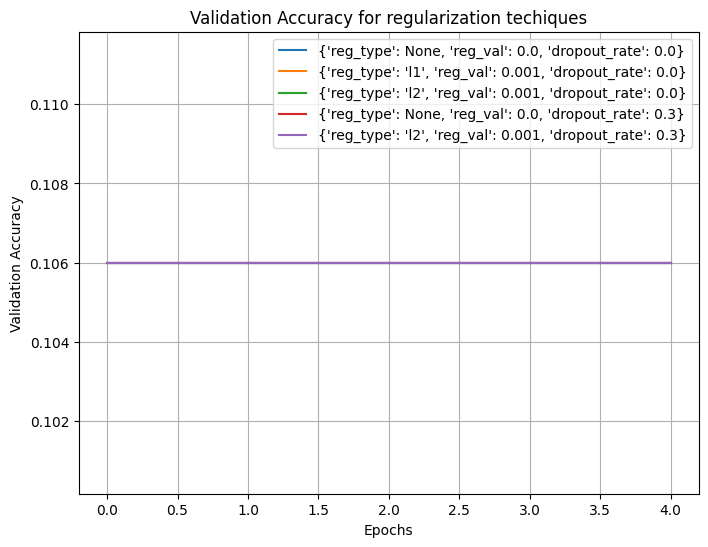

In [ ]:
plt.figure(figsize=(8,6))
for config,hist in history_results.items():
  plt.plot(hist['val_accuracy'],label=config)
plt.title('Validation Accuracy for regularization techiques')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

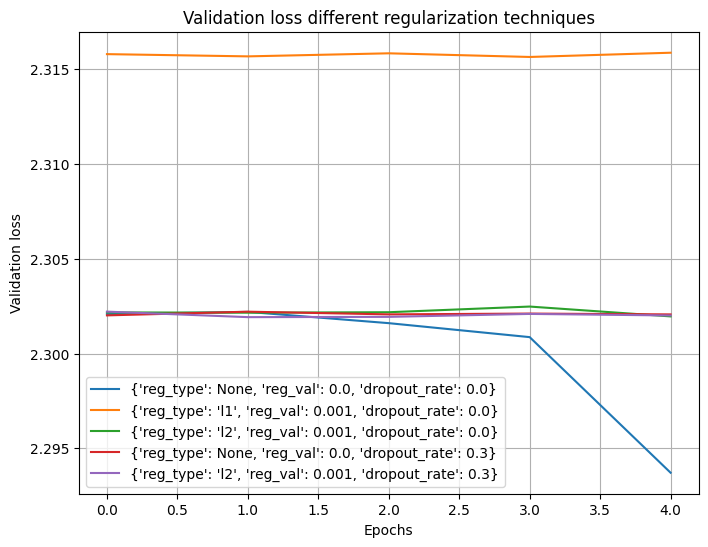

In [ ]:
plt.figure(figsize=(8,6))
for config,hist in history_results.items():
  plt.plot(hist['val_loss'],label=config)
plt.title('Validation loss different regularization techniques')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("\nFinal Test Accuracy Comarission:")
for config,acc in test_results.items():
  print(f"{config}:{acc:.4f}")


Final Test Accuracy Comarission:
{'hidden_unit': 64, 'learning_rate': 0.001, 'batch_size': 32}:0.9738
{'hidden_unit': 128, 'learning_rate': 0.001, 'batch_size': 64}:0.9742
{'hidden_unit': 256, 'learning_rate': 0.001, 'batch_size': 128}:0.9774
